### Necessary Imports

In [1]:
from matplotlib import colors
from matplotlib import pyplot as plt
from astropy.table import Table
import numpy as np
import os
import pandas as pd
import pathlib
import polars as pl

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### First we need to read in all the Gaia information

In [3]:
gaiaids = pl.read_parquet('allgaiadata.parq').to_pandas()
gaiaids['abs_g_mag'] = gaiaids['phot_g_mean_mag'] - 5*np.log10(1000/gaiaids['parallax']) + 5
gaiaids['bp-rp'] = gaiaids['phot_bp_mean_mag'] - gaiaids['phot_rp_mean_mag']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Now let's read in all our good CNN predicted periods

In [4]:
reportedsample = pd.read_csv('reportable.csv', index_col='Unnamed: 0')
reportedsample['bp-rp'] = reportedsample['phot_bp_mean_mag']-reportedsample['phot_rp_mean_mag']
reportedsample['abs_g_mag'] = reportedsample['phot_g_mean_mag'] - 5*np.log10(1000/reportedsample['parallax']) + 5

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Now let's bin the data

In [5]:
minra = np.nanmin(gaiaids['ra_rad'].values)
maxra = np.nanmax(gaiaids['ra_rad'].values)
mindec = np.nanmin(gaiaids['dec_rad'].values)
maxdec = np.nanmax(gaiaids['dec_rad'].values)


minbprp = np.nanmin(gaiaids['bp-rp'].values)
maxbprp = np.nanmax(gaiaids['bp-rp'].values)
mingmag = np.nanmin(gaiaids['abs_g_mag'].values)
maxgmag = np.nanmax(gaiaids['abs_g_mag'].values)


allbins, allx, ally = np.histogram2d(gaiaids['ra_rad'],gaiaids['dec_rad'],bins=200,range=[[minra,maxra],[mindec,maxdec]])
prebins, px, py = np.histogram2d(reportedsample['ra_rad'],reportedsample['dec_rad'], bins=200,range=[[minra,maxra],[mindec,maxdec]])
totdet_fracradec = prebins/allbins


allgaia, allx2, ally2 = np.histogram2d(gaiaids['bp-rp'], gaiaids['abs_g_mag'],bins=250, range=[(minbprp, maxbprp), (mingmag, maxgmag)])
reported, reportedx, reportedy = np.histogram2d(reportedsample['bp-rp'], reportedsample['abs_g_mag'], bins=250, range=[(minbprp, maxbprp), (mingmag, maxgmag)])

truegaia = allgaia.T
truereported = reported.T

detectionfraction = truereported/truegaia
detectionfraction[np.isnan(detectionfraction)] = 0

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_38665/2614501393.py:24: RuntimeWarning: invalid value encountered in divide
  detectionfraction = truereported/truegaia


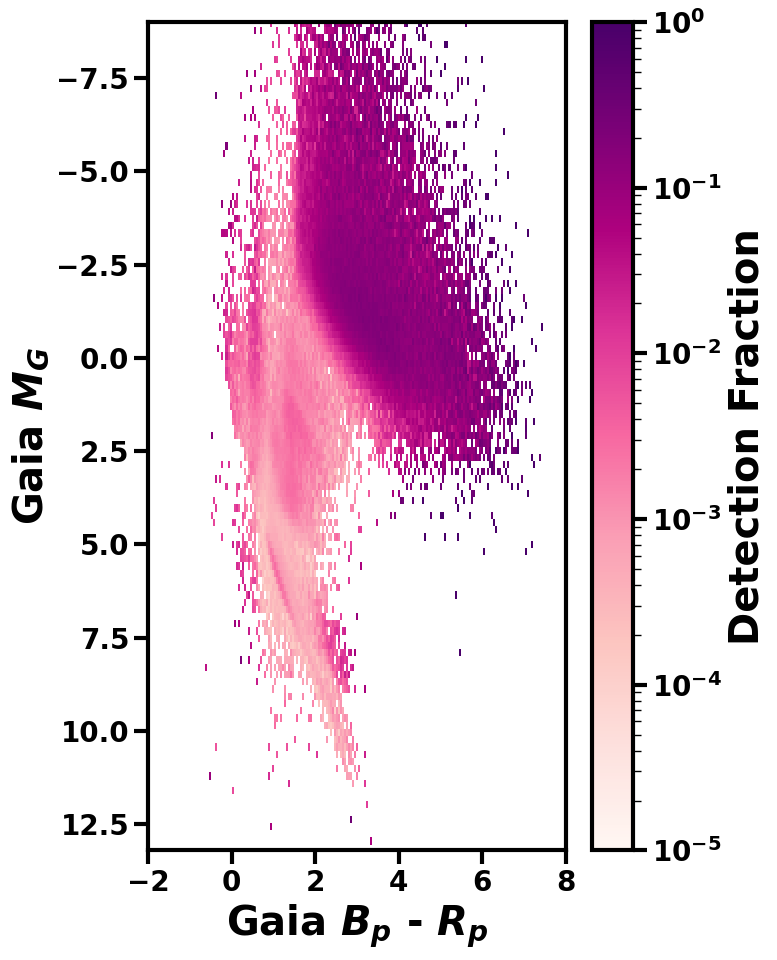

In [6]:
cmap = plt.colormaps['RdPu']
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
ax.set(xlim=(-2, 8), ylim=(13.2, -9), xlabel='Gaia $B_p$ - $R_p$', ylabel=f'Gaia $M_G$')
chehe = ax.pcolormesh(allx2, ally2, detectionfraction, shading='flat', cmap=cmap, norm=colors.LogNorm(vmin=0.00001, vmax=1), rasterized=True)
cbar = fig.colorbar(chehe, ax=ax)
cbar.set_label("Detection Fraction")
plt.tight_layout()
plt.show()

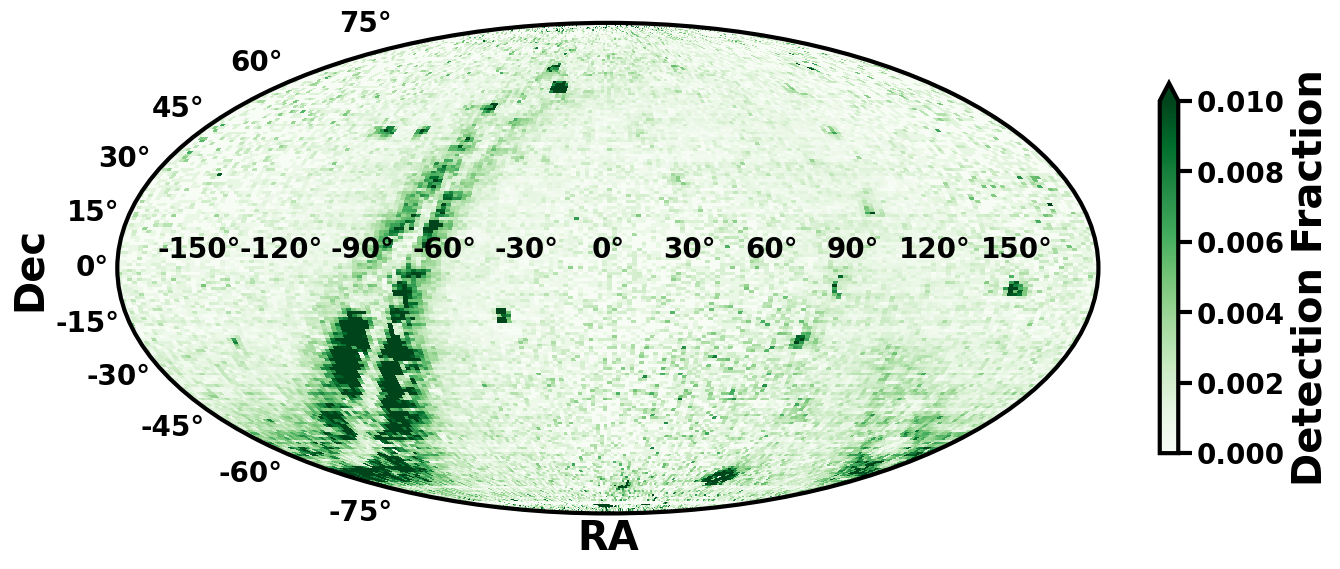

In [7]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='mollweide')
cmap = plt.cm.Greens
ax.pcolor(allx, ally, totdet_fracradec.T, cmap=cmap, shading='auto', vmin=0, vmax=0.01, rasterized=True)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(0, 0.01), cmap=cmap), ax=ax, shrink=0.5,  extend='max')
cbar.set_label("Detection Fraction")
ax.set_ylabel('Dec')
ax.set_xlabel('RA')
plt.tight_layout()
plt.show()